<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 1.2361 acc 0.541 | val loss 0.8542 acc 0.662 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.6536 acc 0.722 | val loss 0.4488 acc 0.816 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.4188 acc 0.813 | val loss 0.3674 acc 0.871 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.3349 acc 0.865 | val loss 0.3597 acc 0.853 *


...

[ConvNeXt-Tiny] Epoch  13/100 | LR: 5.00e-05 | train loss 0.0709 acc 0.961 | val loss 0.4156 acc 0.893


[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.00e-05 | train loss 0.1014 acc 0.966 | val loss 0.4027 acc 0.887


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.00e-06 | train loss 0.0736 acc 0.966 | val loss 0.4520 acc 0.896


[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.00e-06 | train loss 0.0532 acc 0.983 | val loss 0.4353 acc 0.889


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.00e-06 | train loss 0.0382 acc 0.983 | val loss 0.4352 acc 0.889

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 17.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3159)


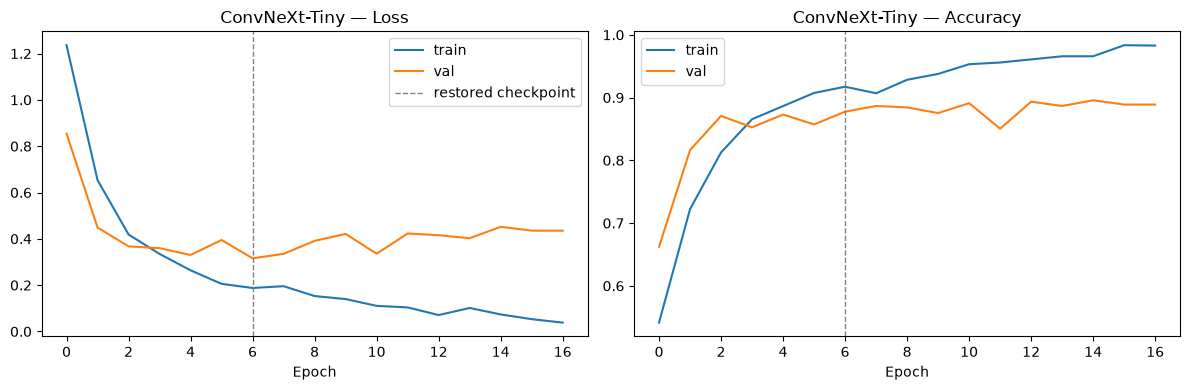

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.690


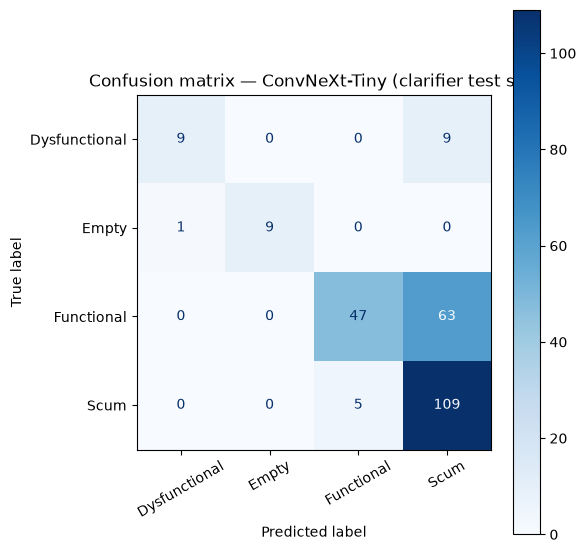

               precision    recall  f1-score   support

Dysfunctional      0.900     0.500     0.643        18
        Empty      1.000     0.900     0.947        10
   Functional      0.904     0.427     0.580       110
         Scum      0.602     0.956     0.739       114

     accuracy                          0.690       252
    macro avg      0.852     0.696     0.727       252
 weighted avg      0.771     0.690     0.671       252



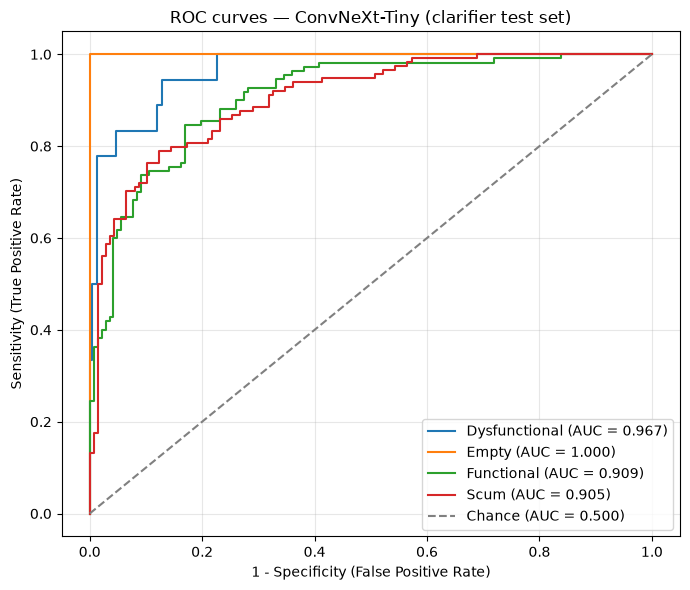

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.967
  Empty          : 1.000
  Functional     : 0.909
  Scum           : 0.905

Mean AUC (over 4/4 classes with test examples): 0.945


(np.float64(0.6904761904761905),
 {'Dysfunctional': 0.9667616334283001,
  'Empty': 1.0,
  'Functional': 0.9085787451984635,
  'Scum': 0.9049707602339181})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_Fisantekraal.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
